# Laboratorio: FrozenLake mediante Q-Learning tabular

En el laboratorio anterior resolvimos `FrozenLake-v1` mediante **Value Iteration**. Allí utilizamos explícitamente el modelo del ambiente: para cada estado y acción conocíamos el estado siguiente y la recompensa.

Ahora resolveremos **el mismo problema**, pero mediante **Q-Learning tabular implementado desde cero**.

La diferencia conceptual es fundamental.

En Value Iteration utilizábamos el modelo:

$$
P(s'|s,a)
$$

para calcular qué ocurriría al ejecutar cada acción.

En Q-Learning no consultaremos esa información. El agente únicamente podrá:

1. observar el estado actual;
2. seleccionar una acción;
3. ejecutar `env.step(action)`;
4. observar la recompensa y el nuevo estado;
5. actualizar el valor de la acción que acaba de experimentar.

La actualización será:

$$
Q(s,a)\leftarrow Q(s,a)+\alpha
\left[
r+\gamma\max_{a'}Q(s',a')-Q(s,a)
\right]
$$

Trabajaremos nuevamente con `FrozenLake-v1` **sin deslizamiento**, para poder comparar directamente este resultado con el laboratorio de Value Iteration.

## 1. Instalación e importaciones

Utilizaremos Gymnasium para proporcionar el ambiente y NumPy para implementar nosotros mismos Q-Learning.

No utilizaremos Stable-Baselines3.

In [ ]:
!pip -q install "gymnasium[toy-text]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 83.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.colors import Normalize
import gymnasium as gym

## 2. Crear FrozenLake determinista

Utilizaremos exactamente el mismo ambiente del laboratorio de Value Iteration:

`is_slippery=False`

Por tanto, cuando el agente selecciona una dirección, el movimiento ejecutado corresponde a esa dirección siempre que las reglas del tablero lo permitan.

Sin embargo, en este laboratorio **no extraeremos `env.unwrapped.P`**.

Q-Learning aprenderá exclusivamente mediante las transiciones que experimente al llamar `env.step(action)`.

In [ ]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

n_states = env.observation_space.n
n_actions = env.action_space.n

desc = env.unwrapped.desc.astype(str)

ACTION_NAMES = {
    0: "LEFT",
    1: "DOWN",
    2: "RIGHT",
    3: "UP",
}

print("Número de estados:", n_states)
print("Número de acciones:", n_actions)
print("\nMapa:")
print(desc)

Número de estados: 16
Número de acciones: 4

Mapa:
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]


## 3. La tabla \(Q\)

FrozenLake tiene 16 estados y 4 acciones.

Por tanto, podemos representar la función:

$$
Q(s,a)
$$

mediante una matriz de dimensiones:

$$
16\times4
$$

Cada fila representa un estado y cada columna una acción.

Inicialmente el agente no conoce cuáles decisiones son convenientes, por lo que comenzaremos con:

$$
Q(s,a)=0
$$

para todos los pares estado–acción.

In [ ]:
Q = np.zeros((n_states, n_actions), dtype=float)

print("Dimensión de Q:", Q.shape)
print(Q)

Dimensión de Q: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## 4. Exploración y explotación

Si el agente seleccionara desde el comienzo:

$$
\arg\max_a Q(s,a)
$$

todas las acciones tendrían inicialmente el mismo valor.

Necesitamos permitirle **explorar**.

Utilizaremos una política \(\epsilon\)-greedy:

- con probabilidad \(\epsilon\), seleccionamos una acción aleatoria;
- con probabilidad \(1-\epsilon\), seleccionamos una de las acciones con mayor valor conocido.

Para evitar favorecer siempre la primera acción cuando existen empates, escogeremos aleatoriamente entre todas las acciones que comparten el máximo valor.

In [ ]:
def greedy_action(Q, state):
    values = Q[state]
    best_actions = np.flatnonzero(np.isclose(values, values.max()))
    return int(np.random.choice(best_actions))


def epsilon_greedy_action(Q, state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()

    return greedy_action(Q, state)

## 5. Una transición de Q-Learning

Supongamos que el agente se encuentra en \(s\) y selecciona \(a\).

El ambiente responde:

$$
(s,a)\longrightarrow(r,s')
$$

Entonces calculamos el objetivo temporal:

$$
\text{target}
=
r+\gamma\max_{a'}Q(s',a')
$$

y corregimos solamente el valor de la acción que acabamos de experimentar:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
[
\text{target}-Q(s,a)
]
$$

Si \(s'\) es terminal, no existe valor futuro y utilizamos simplemente:

$$
\text{target}=r
$$

La siguiente función implementa **un solo paso de interacción y aprendizaje**.

In [ ]:
def q_learning_step(Q, state, alpha, gamma, epsilon):
    action = epsilon_greedy_action(Q, state, epsilon)

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    if done:
        target = reward
    else:
        target = reward + gamma * np.max(Q[next_state])

    old_value = Q[state, action]

    Q[state, action] = old_value + alpha * (target - old_value)

    info_step = {
        "state": state,
        "action": action,
        "action_name": ACTION_NAMES[action],
        "reward": reward,
        "next_state": next_state,
        "old_q": old_value,
        "target": target,
        "new_q": Q[state, action],
        "done": done,
    }

    return next_state, done, info_step

## 6. Visualizar los cuatro valores de acción

Mantendremos la misma representación utilizada en el laboratorio de Value Iteration.

Cada celda del tablero se divide mediante sus diagonales en cuatro regiones:

- izquierda: `LEFT`;
- abajo: `DOWN`;
- derecha: `RIGHT`;
- arriba: `UP`.

Cada región muestra el valor aprendido de la correspondiente acción.

Así podemos observar directamente cómo se va construyendo la tabla Q durante la experiencia.

In [ ]:
def plot_q_values(Q, episode=None, cmap="viridis"):
    rows, cols = desc.shape

    fig, ax = plt.subplots(figsize=(8, 8))

    q_min = float(np.min(Q))
    q_max = float(np.max(Q))

    if np.isclose(q_min, q_max):
        q_min -= 0.5
        q_max += 0.5

    norm = Normalize(vmin=q_min, vmax=q_max)
    cm = plt.get_cmap(cmap)

    for row in range(rows):
        for col in range(cols):
            s = row * cols + col

            x0 = col
            x1 = col + 1
            y0 = rows - row - 1
            y1 = y0 + 1
            xc = col + 0.5
            yc = y0 + 0.5

            triangles = {
                0: [(x0, y0), (x0, y1), (xc, yc)],  # LEFT
                1: [(x0, y0), (x1, y0), (xc, yc)],  # DOWN
                2: [(x1, y0), (x1, y1), (xc, yc)],  # RIGHT
                3: [(x0, y1), (x1, y1), (xc, yc)],  # UP
            }

            text_positions = {
                0: (col + 0.16, yc),
                1: (xc, y0 + 0.16),
                2: (col + 0.84, yc),
                3: (xc, y0 + 0.84),
            }

            for a in range(n_actions):
                value = Q[s, a]

                patch = Polygon(
                    triangles[a],
                    closed=True,
                    facecolor=cm(norm(value)),
                    edgecolor="white",
                    linewidth=0.7,
                )
                ax.add_patch(patch)

                tx, ty = text_positions[a]
                ax.text(
                    tx,
                    ty,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                )

            ax.add_patch(
                Rectangle(
                    (x0, y0),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.5,
                )
            )

            cell = desc[row, col]

            if cell in ("H", "G"):
                center = f"{s}\n{cell}"
            else:
                center = f"{s}\n{cell}\nV={np.max(Q[s]):.2f}"

            ax.text(
                xc,
                yc,
                center,
                ha="center",
                va="center",
                fontsize=8,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    fc="white",
                    alpha=0.8,
                ),
            )

    title = "FrozenLake — Q-Learning"
    if episode is not None:
        title += f" — episodio {episode}"

    ax.set_title(title)
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cm)
    sm.set_array([])
    fig.colorbar(
        sm,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        label="Q(s,a)",
    )

    plt.show()

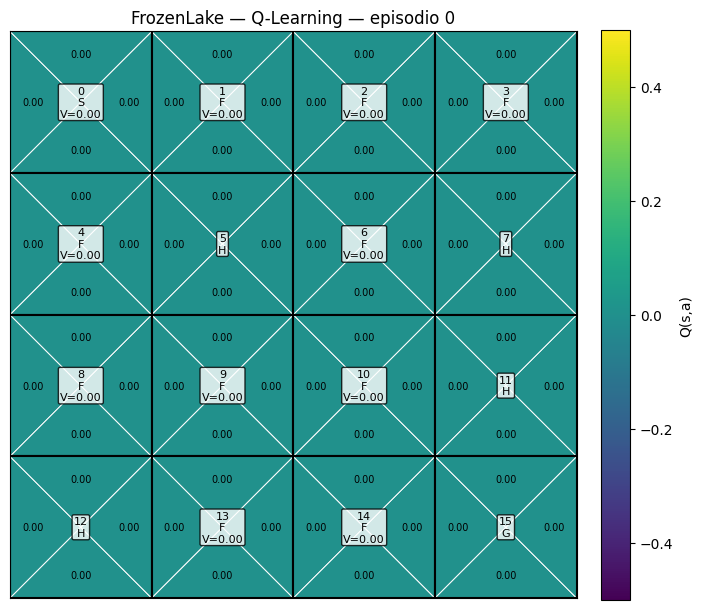

In [ ]:
plot_q_values(Q, episode=0)

## 7. Parámetros del aprendizaje

Utilizaremos tres parámetros principales.

### Tasa de aprendizaje

$$
\alpha
$$

controla cuánto modificamos el valor conocido después de una nueva experiencia.

### Factor de descuento

$$
\gamma
$$

determina cuánto valoramos las recompensas futuras.

### Exploración

$$
\epsilon
$$

controla la probabilidad de seleccionar una acción aleatoria.

Comenzaremos con una exploración elevada y la reduciremos progresivamente.

In [ ]:
alpha = 0.4
gamma = 0.95

epsilon_initial = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

max_steps_per_episode = 100

## 8. Reiniciar Q-Learning

Esta celda permite regresar completamente al comienzo del aprendizaje.

Puede ejecutarla siempre que quiera repetir el experimento con otros parámetros.

Q-Learning reiniciado.


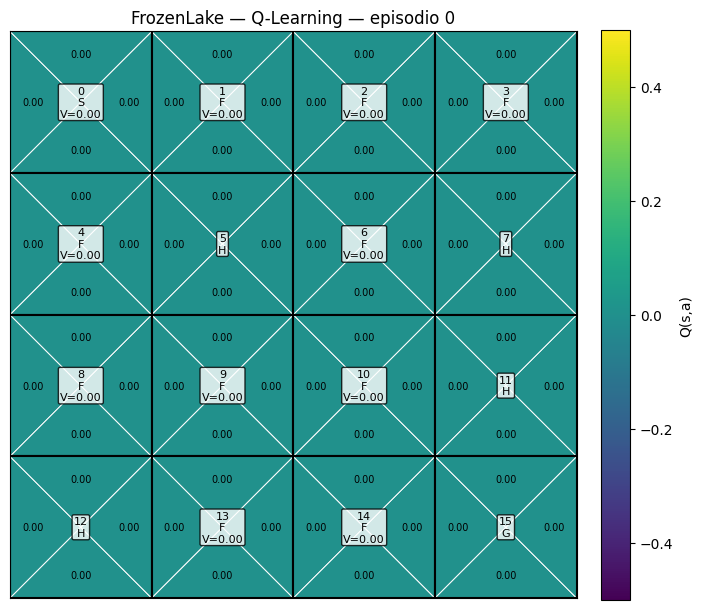

In [ ]:
Q = np.zeros((n_states, n_actions), dtype=float)

episode = 0
epsilon = epsilon_initial

episode_rewards = []
episode_steps = []
epsilon_history = []

print("Q-Learning reiniciado.")
plot_q_values(Q, episode=episode)

## 9. Aprender un episodio

A diferencia de Value Iteration, aquí una iteración matemática sobre todos los estados no es la unidad natural del algoritmo.

La unidad experimental será **un episodio**.

En cada episodio:

1. FrozenLake comienza en `S`;
2. el agente selecciona acciones mediante epsilon-greedy;
3. observa las transiciones producidas por `env.step`;
4. actualiza Q después de cada transición;
5. termina al alcanzar `H`, `G` o el límite de pasos.

Puede ejecutar repetidamente la siguiente celda para observar el aprendizaje episodio por episodio.

Episodio: 1
Recompensa: 0
Pasos: 13
Epsilon para el próximo episodio: 0.9950


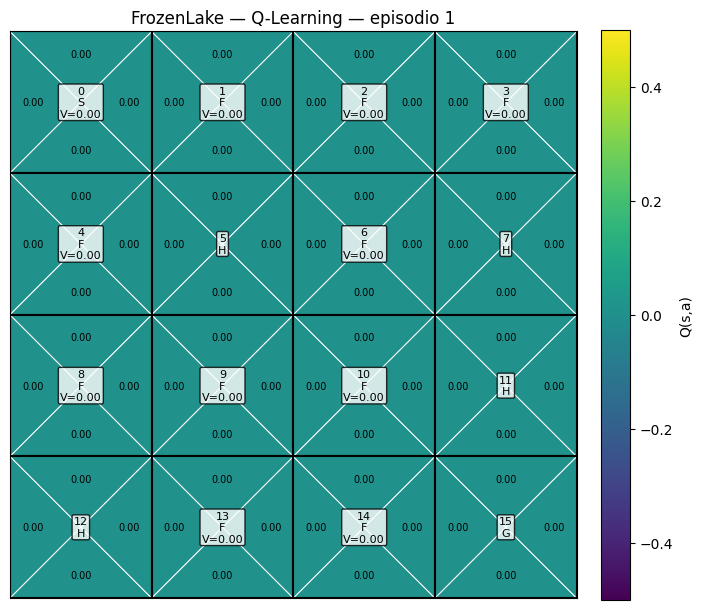

In [ ]:
state, info = env.reset()

done = False
total_reward = 0
steps = 0

while not done and steps < max_steps_per_episode:
    state, done, step_info = q_learning_step(
        Q,
        state,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
    )

    total_reward += step_info["reward"]
    steps += 1

episode += 1

episode_rewards.append(total_reward)
episode_steps.append(steps)
epsilon_history.append(epsilon)

epsilon = max(epsilon_min, epsilon * epsilon_decay)

print(f"Episodio: {episode}")
print(f"Recompensa: {total_reward}")
print(f"Pasos: {steps}")
print(f"Epsilon para el próximo episodio: {epsilon:.4f}")

plot_q_values(Q, episode=episode)

## 10. Inspeccionar una actualización individual

Para comprender con precisión la ecuación de Q-Learning podemos reiniciar el ambiente y realizar **una sola transición**.

La celda muestra:

- estado actual;
- acción seleccionada;
- recompensa;
- estado siguiente;
- valor Q anterior;
- target;
- nuevo valor Q.

Esto permite observar directamente la ecuación de actualización.

In [ ]:
state, info = env.reset()

next_state, done, step_info = q_learning_step(
    Q,
    state,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
)

for key, value in step_info.items():
    print(f"{key:12s}: {value}")

state       : 0
action      : 3
action_name : UP
reward      : 0
next_state  : 0
old_q       : 0.0
target      : 0.0
new_q       : 0.0
done        : False


## 11. Ejecutar varios episodios seguidos

Después de comprender el proceso episodio por episodio, podemos ejecutar muchos episodios automáticamente.

Esta función continúa aprendiendo a partir de la tabla Q actual.

In [ ]:
from tqdm import tqdm
def train_episodes(
    Q,
    n_episodes,
    start_episode,
    epsilon,
    alpha=0.4,
    gamma=0.95,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    max_steps=100,
):
    rewards = []
    steps_history = []
    eps_history = []

    for _ in tqdm(range(n_episodes)):
        state, info = env.reset()

        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            state, done, step_info = q_learning_step(
                Q,
                state,
                alpha=alpha,
                gamma=gamma,
                epsilon=epsilon,
            )

            total_reward += step_info["reward"]
            steps += 1

        rewards.append(total_reward)
        steps_history.append(steps)
        eps_history.append(epsilon)

        epsilon = max(
            epsilon_min,
            epsilon * epsilon_decay
        )

    return (
        Q,
        start_episode + n_episodes,
        epsilon,
        rewards,
        steps_history,
        eps_history,
    )

100%|██████████| 50000/50000 [00:38<00:00, 1305.64it/s]


Episodio alcanzado: 105001
Epsilon actual: 0.0500


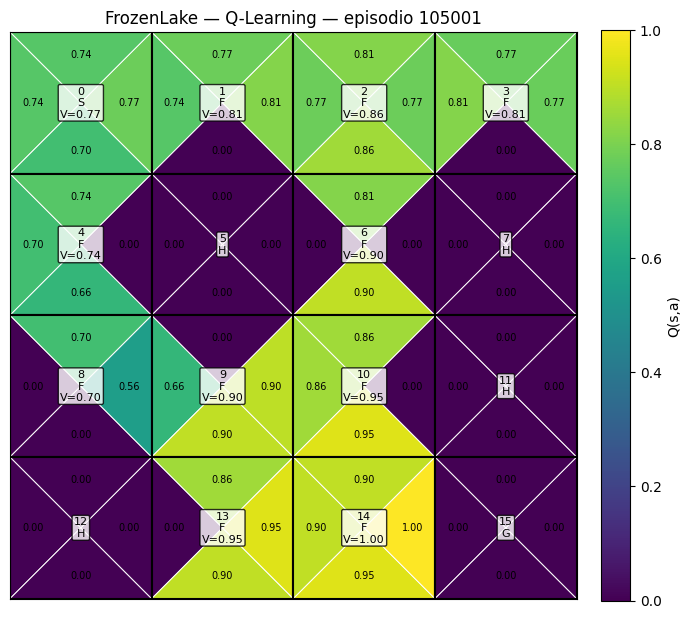

In [ ]:
epsilon_initial = 1.0
epsilon_min = 0.05
n_episodes=50000
epsilon_decay=(epsilon_min/epsilon_initial)**(1/n_episodes)
Q, episode, epsilon, rewards, steps_hist, eps_hist = train_episodes(
    Q,
    n_episodes=n_episodes,
    start_episode=episode,
    epsilon=epsilon,
    alpha=alpha,
    gamma=gamma,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    max_steps=max_steps_per_episode,
)

episode_rewards.extend(rewards)
episode_steps.extend(steps_hist)
epsilon_history.extend(eps_hist)

print(f"Episodio alcanzado: {episode}")
print(f"Epsilon actual: {epsilon:.4f}")

plot_q_values(Q, episode=episode)

## 12. Observar la evolución del entrenamiento

FrozenLake entrega recompensa 1 al alcanzar la meta y 0 en los demás casos.

Por ello, la recompensa de cada episodio también puede interpretarse como:

- `1`: el agente alcanzó la meta;
- `0`: el episodio terminó sin alcanzarla.

Una media móvil de las recompensas permite observar cómo cambia la tasa reciente de éxito.

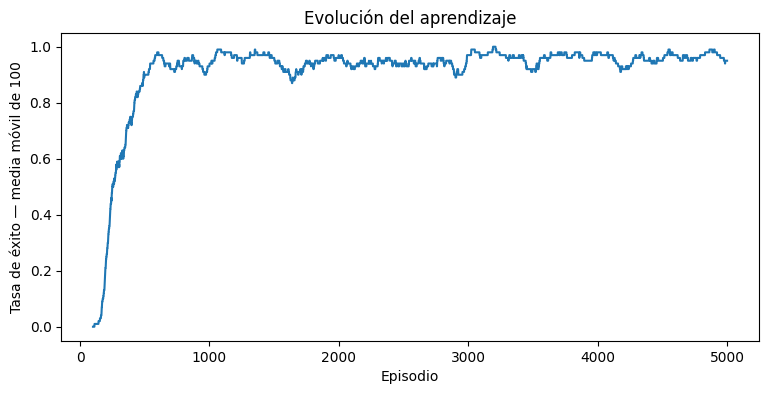

In [ ]:
rewards_array = np.asarray(episode_rewards, dtype=float)

window = min(100, len(rewards_array))

if window > 0:
    moving_success = np.convolve(
        rewards_array,
        np.ones(window) / window,
        mode="valid",
    )

    plt.figure(figsize=(9, 4))
    plt.plot(
        np.arange(window, len(rewards_array) + 1),
        moving_success,
    )
    plt.xlabel("Episodio")
    plt.ylabel(f"Tasa de éxito — media móvil de {window}")
    plt.title("Evolución del aprendizaje")
    plt.ylim(-0.05, 1.05)
    plt.show()

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(epsilon_history)
plt.xlabel("Episodio")
plt.ylabel("Epsilon")
plt.title("Reducción de la exploración")
plt.show()

## 13. Extraer la política aprendida

Una vez entrenada la tabla Q, podemos obtener una política mediante:

$$
\pi(s)=\arg\max_a Q(s,a)
$$

La política seleccionará en cada estado una de las acciones con mayor valor aprendido.

In [ ]:
ARROWS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑",
}

policy = np.argmax(Q, axis=1)

policy_symbols = []

for s in range(n_states):
    cell = desc.flat[s]

    if cell == "H":
        policy_symbols.append("H")
    elif cell == "G":
        policy_symbols.append("G")
    else:
        policy_symbols.append(ARROWS[policy[s]])

policy_grid = np.array(policy_symbols).reshape(desc.shape)

print("Política aprendida:")
print(policy_grid)

## 14. Pintar la política sobre FrozenLake

Ahora reemplazaremos los cuatro valores Q por una única flecha correspondiente a la acción seleccionada en cada estado.

También mostraremos:

\[
V(s)=\max_a Q(s,a)
\]

como el valor asociado al estado según la tabla aprendida.

In [ ]:
def plot_policy(Q):
    rows, cols = desc.shape
    policy = np.argmax(Q, axis=1)

    fig, ax = plt.subplots(figsize=(6, 6))

    for row in range(rows):
        for col in range(cols):
            s = row * cols + col

            x = col
            y = rows - row - 1
            cell = desc[row, col]

            ax.add_patch(
                Rectangle(
                    (x, y),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.5,
                )
            )

            if cell in ("H", "G"):
                symbol = cell
            else:
                symbol = ARROWS[policy[s]]

            ax.text(
                x + 0.5,
                y + 0.60,
                symbol,
                ha="center",
                va="center",
                fontsize=24,
            )

            ax.text(
                x + 0.5,
                y + 0.22,
                f"s={s}\nV={np.max(Q[s]):.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    ax.set_title("Política aprendida mediante Q-Learning")
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    plt.show()

plot_policy(Q)

## 15. Evaluar la política sin exploración

Durante el entrenamiento necesitábamos exploración.

Durante la evaluación queremos medir la política que el agente realmente aprendió, por lo que utilizaremos siempre una acción greedy.

Ejecutaremos varios episodios y calcularemos la proporción de veces que el agente alcanza la meta.

In [ ]:
def evaluate_policy(Q, n_episodes=100):
    successes = 0
    lengths = []

    for _ in range(n_episodes):
        state, info = env.reset()

        done = False
        steps = 0

        while not done and steps < max_steps_per_episode:
            action = int(np.argmax(Q[state]))

            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            steps += 1

            if reward == 1:
                successes += 1

        lengths.append(steps)

    return successes / n_episodes, np.mean(lengths)


success_rate, mean_length = evaluate_policy(Q, n_episodes=100)

print(f"Tasa de éxito: {success_rate:.2%}")
print(f"Longitud media del episodio: {mean_length:.2f}")

Tasa de éxito: 100.00%
Longitud media del episodio: 6.00


## 16. Value Iteration frente a Q-Learning

Hemos resuelto ahora **el mismo FrozenLake de dos maneras diferentes**.

### Value Iteration

Value Iteration conocía el modelo:

$$
P(s'|s,a)
$$

y podía evaluar sistemáticamente todas las acciones de todos los estados.

Su actualización era:

$$
V_{k+1}(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')+\gamma V_k(s')
\right]
$$

No necesitaba recorrer físicamente el ambiente para descubrir qué producía cada acción.

### Q-Learning

Q-Learning no utilizó el modelo de transición.

El conocimiento llegó mediante experiencias:

$$
(s,a,r,s')
$$

y cada experiencia modificó solamente un elemento de la tabla:

$$
Q(s,a)
$$

mediante:

$$
Q(s,a)\leftarrow Q(s,a)+\alpha
\left[
r+\gamma\max_{a'}Q(s',a')-Q(s,a)
\right]
$$

Esta diferencia puede resumirse como:

```text
VALUE ITERATION
conoce el modelo P
        ↓
evalúa las transiciones
        ↓
propaga valores mediante Bellman
        ↓
obtiene la política


Q-LEARNING
no conoce el modelo P
        ↓
interactúa con el ambiente
        ↓
observa (s,a,r,s')
        ↓
actualiza Q(s,a)
        ↓
obtiene la política
```

Q-Learning introduce además un nuevo problema: **exploración frente a explotación**.

El agente necesita experimentar acciones para descubrir su valor, pero progresivamente debe utilizar el conocimiento que ya ha adquirido.

Este laboratorio constituye también el puente natural hacia DQN.

Mientras aquí podemos almacenar:

$$
Q(s,a)
$$

en una tabla de solamente \(16\times4\), en problemas con espacios de estados grandes o continuos esa representación deja de ser práctica.

La idea siguiente será entonces sustituir la tabla por un aproximador:

$$
Q(s,a;\theta)
$$

por ejemplo, una red neuronal.